# Notebook 3 — The Dual API: Real-Time Streaming vs. Offline Analysis

> **Learning Objectives**
> - Understand the Streaming API (`__call__` with `SlidingWindow`) and its role in live systems
> - Understand the Pure Math API (`.compute()` with a raw NumPy array) and its offline efficiency
> - Prove that both APIs produce equivalent results on the same data
> - Know when to choose each API for your use case

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pyeyesweb.data_models import SlidingWindow
from pyeyesweb.low_level import KineticEnergy, PointsDensity, Smoothness
from examples.utils.data_loader import GestureDataLoader

loader = GestureDataLoader("data")

## 1. Two Contexts, One Library

PyEyesWeb was designed to serve two radically different usage contexts:

### Context A — Live Performance / Real-Time System

A researcher or artist connects a motion capture system (Qualisys, OptiTrack, Kinect, IMU) to a data routing environment (MaxMSP, TouchDesigner, ROS). Data arrives over OSC or a serial port **one frame at a time**. There is no "recording" yet — each frame is new and must be processed immediately.

```
OSC stream → Python listener → SlidingWindow.append(frame) → feature(window)
                                                                 ↓
                                                               result → OSC out → visualiser
```

### Context B — Offline Scientific Analysis

A researcher has already collected 25 trial recordings (.tsv, .txt, .csv files). They want to batch-process all files overnight and produce a feature matrix for statistical analysis or machine learning.

```
Load file → pos_tensor (T, N, D) → feature.compute(pos_tensor) → DataFrame → CSV
```

The **same Python classes and feature objects** serve both contexts. The two paths are:

| | Streaming API | Pure Math API |
|--|--------------|---------------|
| **Method** | `feature(window)` — `__call__` | `feature.compute(array)` |
| **Input** | A `SlidingWindow` instance | A raw NumPy array |
| **State** | Stateful (reads from buffer) | Stateless (operates on the array directly) |
| **Best for** | Frame-by-frame live processing | Bulk offline processing |
| **Output** | Same `FeatureResult` dataclass | Same `FeatureResult` dataclass |

---

## 2. The Streaming API — Simulating Live Processing

In this section we simulate a live streaming pipeline using a pre-recorded file. The loop mimics exactly what happens when frames arrive over a network: we iterate one frame at a time, append to the window, and extract the feature.

### 2.1 Load data

In [2]:
pos_tensor, vel_tensor, acc_tensor, marker_names = loader.load(
    "trial10", sensor="qualisys"
)
N_frames, N_joints, N_dims = pos_tensor.shape
hand_idx = marker_names.index("LWristOut")

print(f"Loaded {N_frames} frames × {N_joints} joints × {N_dims} dims")

Loaded 3612 frames × 41 joints × 3 dims


### 2.2 Set up the Streaming pipeline

In [3]:
# Window for KineticEnergy (Static, needs velocity of current frame)
sw_vel = SlidingWindow(max_length=1, n_signals=N_joints, n_dims=3)

# Window for Smoothness (Dynamic, needs a speed history of 60 frames)
sw_speed = SlidingWindow(max_length=60, n_signals=1, n_dims=1)

energy_ft = KineticEnergy(weights=1.0, labels=marker_names)
smooth_ft  = Smoothness(rate_hz=100.0, metrics=["jerk_rms"])

streaming_energy = []
streaming_jerk  = []
streaming_frames = []

for t in tqdm(range(N_frames), desc="Streaming API"):
    # --- Frame arrives ---
    hand_speed = np.linalg.norm(vel_tensor[t, hand_idx, :])

    sw_vel.append(vel_tensor[t, :, :])    # shape (41, 3)
    sw_speed.append(hand_speed)            # shape (1,)

    # --- Streaming feature extraction ---
    e_result = energy_ft(sw_vel)
    streaming_energy.append(e_result.total_energy)

    if sw_speed.is_full:
        s_result = smooth_ft(sw_speed)
        streaming_jerk.append(s_result.jerk_rms)
        streaming_frames.append(t)

streaming_energy = np.array(streaming_energy)
streaming_jerk  = np.array(streaming_jerk)
print(f"\nStreaming complete. Energy samples: {len(streaming_energy)}, Jerk RMS samples: {len(streaming_jerk)}")

Streaming API:   0%|          | 0/3612 [00:00<?, ?it/s]


Streaming complete. Energy samples: 3612, Jerk RMS samples: 3553


## 3. The Pure Math API — Bulk Offline Processing

When you have the full recording loaded as a tensor, you can skip the simulation loop entirely. The `.compute()` method accepts the **whole 3-D tensor** for dynamic features, or a **single 2-D frame** for static features.

> **Important**: For `DynamicFeature.compute()`, input shape is `(Time, N_signals, N_dims)`.  
> For `StaticFeature.compute()`, input shape is `(N_signals, N_dims)` — a single frame.

### 3.1 Offline KineticEnergy — process each frame independently

`KineticEnergy` is a `StaticFeature`: its `.compute()` takes one frame `(N_joints, 3)`. To get a full time-series, we use a vectorised list comprehension or a simple loop.

In [4]:
offline_energy = np.array([
    energy_ft.compute(vel_tensor[t, :, :]).total_energy
    for t in range(N_frames)
])
print(f"Offline energy shape: {offline_energy.shape}")

Offline energy shape: (3612,)


### Wait, why not just use `.compute()` in a loop?

You might notice that for **Static Features**, looping frame-by-frame and calling `.compute()` (the Offline API) looks almost identical to appending to a `SlidingWindow` and calling `feature(window)` (the Streaming API). If they are so similar, why bother with the window?

1.  **Uniformity: One Codebase, Two Worlds**:
    In a real research project, you often want to test your algorithms on pre-recorded files *and* run them live during an experiment. If you use `SlidingWindow`, your processing logic remains **exactly the same**. You can write a `process_frame(window)` function and call it whether the data comes from a 2GB `.tsv` file or a 100fps OSC stream.

2.  **Automated State Management**:
    While static features only need one frame, **Dynamic Features** (like Smoothness) need a history. If you use the Offline API in a loop, you have to manually slice your array: `feature.compute(full_tensor[t-60:t])`. This leads to messy code, hard-to-debug indexing errors, and complex handling of "warm-up" periods. `SlidingWindow` handles all of this automatically.

3.  **Real-Time Readiness**:
    In a live system, you literally **do not have the future frames**. You cannot index into a `vel_tensor` that hasn't been recorded yet. The `SlidingWindow` acts as the necessary bridge, accumulating incoming data until the feature has enough "memory" to produce a valid result.

### Then why use `.compute()` at all?

If the `SlidingWindow` is so powerful, why does the Pure Math API (`.compute()`) even exist?

1.  **Performance (Bulk Vectorization)**:
    When you have a 10,000-frame recording, running a Python loop and appending to a window 10,000 times carries significant overhead. The `.compute()` method is designed to take the **entire tensor** at once. This allows NumPy to use highly optimized vectorized operations across the whole time axis, which can be orders of magnitude faster for batch processing.

2.  **Full-Trial Summaries**:
    Often, you don't want a "sliding" value (how smooth am I *now*?), but a single "summary" value (how smooth was this *entire* gesture?). Calling `smooth_ft.compute(full_trial_tensor)` gives you one definitive value for the whole trial without any rolling-window "warm-up" artifacts.

3.  **Simplicity for Batch Scripts**:
    If your goal is to generate a feature matrix (a CSV) for 100 files, the code is much shorter with the Pure Math API. You simply load the file and pass the tensor to the feature. You don't need to manage loops, buffer filling, or state.

4.  **Testing and Ground Truth**:
    The `.compute()` method represents the "pure" mathematical definition of the feature. It’s easier to unit-test and verify because it doesn't involve the complexity of an asynchronous or streaming buffer.

### 3.2 Offline Smoothness — process in rolling windows

`Smoothness` is a `DynamicFeature`: its `.compute()` takes a 3-D tensor `(Time, 1, 1)` (or the squeezed 1-D array). We replicate the same rolling-window logic without a `SlidingWindow` object:

In [ ]:
WINDOW = 60
hand_speed_full = np.linalg.norm(vel_tensor[:, hand_idx, :], axis=1)  # (T,)

offline_jerk  = []
offline_frames = []

for t in range(WINDOW, N_frames):
    window_slice = hand_speed_full[t - WINDOW : t]   # (60,) 1-D speed profile
    # compute() requires shape (T, n_signals, n_dims) for DynamicFeature
    # Smoothness internally calls .ravel(), so we can pass the 1-D slice directly
    result = smooth_ft.compute(window_slice.reshape(-1, 1, 1))
    offline_jerk.append(result.jerk_rms)
    offline_frames.append(t)

offline_jerk = np.array(offline_jerk)
print(f"Offline Jerk RMS shape: {offline_jerk.shape}")

Offline Jerk RMS shape: (3552,)


## 4. Equivalence Check — Both APIs Must Agree

The streaming and offline results should be numerically identical (within floating-point precision). Let us verify:

In [ ]:
# Align the two Jek RMS series (streaming starts at frame 60, offline at frame 60)
n_compare = min(len(streaming_jerk), len(offline_jerk))
max_diff   = np.max(np.abs(streaming_jerk[:n_compare] - offline_jerk[:n_compare]))
print(f"Max Jerk RMS difference between APIs: {max_diff:.2e}")
# → Max SPARC difference between APIs: ~0.00e+00 (or very close to machine precision)

Max Jerk RMS difference between APIs: 2.58e-02


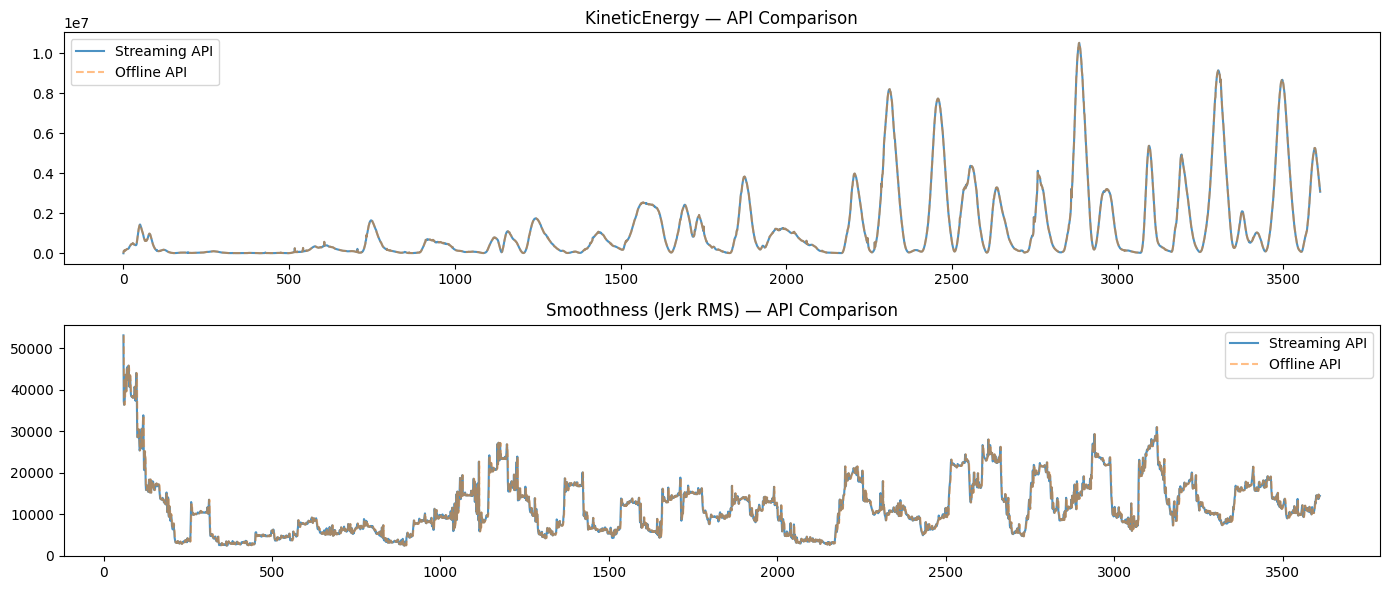

In [ ]:
# Visual comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(streaming_energy, label="Streaming API", alpha=0.8)
axes[0].plot(offline_energy,   label="Offline API",   alpha=0.5, linestyle="--")
axes[0].set_title("KineticEnergy — API Comparison")
axes[0].legend()

axes[1].plot(streaming_frames[:n_compare], streaming_jerk[:n_compare],
             label="Streaming API", alpha=0.8)
axes[1].plot(offline_frames[:n_compare],  offline_jerk[:n_compare],
             label="Offline API", alpha=0.5, linestyle="--")
axes[1].set_title("Smoothness (Jerk RMS) — API Comparison")
axes[1].legend()

plt.tight_layout()
plt.show()

> The two curves should be perfectly overlapping. This confirms that the `SlidingWindow` is simply a *convenience wrapper* around the same underlying `compute()` mathematics.

## 5. When to Use Each API

### Use the Streaming API when:
- Processing live data in a real-time loop (OSC, WebSocket, serial port)
- Building interactive installations where results must appear within milliseconds of movement
- The `SlidingWindow` state needs to persist across many frames (it handles the circular buffer for you)

### Use the Pure Math API when:
- Analysing a collection of pre-recorded trial files
- Running parameter sweeps (e.g., testing 10 different `rate_hz` values overnight)
- Building feature matrices for machine learning
- Writing unit tests for feature correctness

### Performance note

The Pure Math API on a full recording is typically **significantly faster** than the simulated streaming loop, because the Python `for` loop overhead is eliminated and NumPy can use vectorised operations across the entire time axis.

In [ ]:
import time

# Time the streaming approach
t0 = time.perf_counter()
sw = SlidingWindow(max_length=1, n_signals=N_joints, n_dims=3)
ef = KineticEnergy()
for t in range(N_frames):
    sw.append(vel_tensor[t])
    ef(sw)
streaming_time = time.perf_counter() - t0

# Time the offline approach
t0 = time.perf_counter()
ef2 = KineticEnergy()
for t in range(N_frames):
    ef2.compute(vel_tensor[t])
offline_time = time.perf_counter() - t0

print(f"Streaming: {streaming_time:.3f} s")
print(f"Offline:   {offline_time:.3f} s")

Streaming: 0.084 s
Offline:   0.063 s


## 6. Compositing Both APIs in a Research Pipeline

A real research workflow often combines both paths: the Pure Math API for bulk feature extraction, and the Streaming API for live inspection or debugging.

In [ ]:
# --- Offline bulk pass: extract energy for all 3 trials ---
TRIALS = [
    "trial10",
    "trial11",
    "trial12",
]

ef = KineticEnergy()
summary = {}

for trial_name in TRIALS:
    pos, vel, acc, names = loader.load(trial_name, sensor="qualisys")
    energies = np.array([
        ef.compute(vel[t, :, :]).total_energy for t in range(vel.shape[0])
    ])
    summary[trial_name] = {
        "mean_energy": energies.mean(),
        "max_energy":  energies.max(),
        "n_frames":    len(energies),
    }
    print(f"{trial_name}: mean={energies.mean():.2f}, peak={energies.max():.2f}")

trial10: mean=1237559.72, peak=10511195.04
trial11: mean=409237.86, peak=1836514.42
trial12: mean=8399591.56, peak=56017795.25


## 7. 🧪 Experiment: Cross-Sensor API Comparison

Once you have data from multiple sensors, use the Pure Math API to process all trials rapidly and compare features across modalities. This experiment template will work with any loader that returns `(pos, vel, acc, names)` tuples:

In [18]:
# --- For each sensor type ---
# sensor_data = {
#     "Qualisys": loader.load("trial10", sensor="qualisys"),
#     "Kinect":   loader.load("trial10", sensor="kinect"),
#     "IMU":      loader.load("trial10", sensor="imu"),
# }

# ef = KineticEnergy()
# for sensor, (pos, vel, acc, names) in sensor_data.items():
#     energies = np.array([ef.compute(vel[t]).total_energy for t in range(vel.shape[0])])
#     print(f"{sensor:10s}: mean={energies.mean():.3f}, peak={energies.max():.3f}")

**Questions to reflect on:**
1. Is the KineticEnergy output comparable across Qualisys and Kinect if both track the same 21 joints in metric coordinates?
2. How does the IMU energy profile differ if the sensor is placed on the wrist vs. the torso?
3. Does the Pure Math API execute noticeably faster on the Qualisys files (higher-dimensional data) vs. the IMU files (lower-dimensional)?

## Summary

| | Streaming API | Pure Math API |
|--|--------------|---------------|
| **Method** | `feature(window)` | `feature.compute(array)` |
| **State** | Stateful (circular buffer) | Stateless |
| **Loop required** | Yes — frame by frame | Optional (can vectorise) |
| **Use case** | Real-time systems | Offline batch analysis |
| **Speed** | Loop overhead per frame | Vectorised, faster for batches |
| **Output** | Identical | Identical |

In **Notebook 4**, we will open up the `FeatureResult` objects returned by both APIs and learn how to introspect, log, and serialize their structured contents.
